📂 发现 8 个文件，正在绘图...


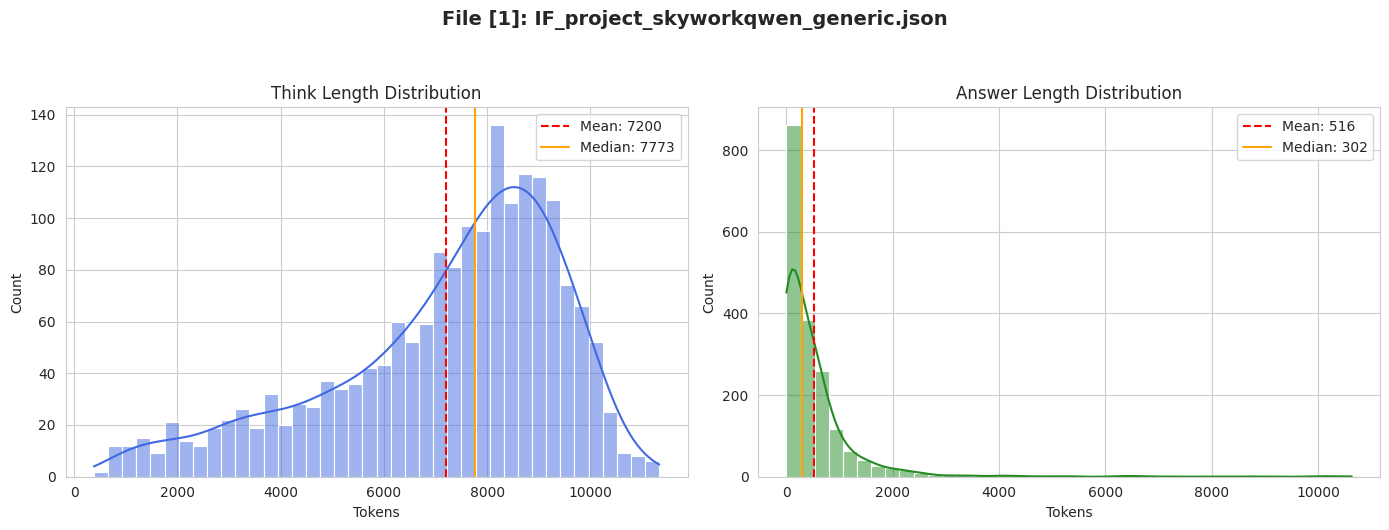

----------------------------------------------------------------------------------------------------
❌ 处理 agent_default_project_skyworkqwen_generic.json 时出错: Expected object or value


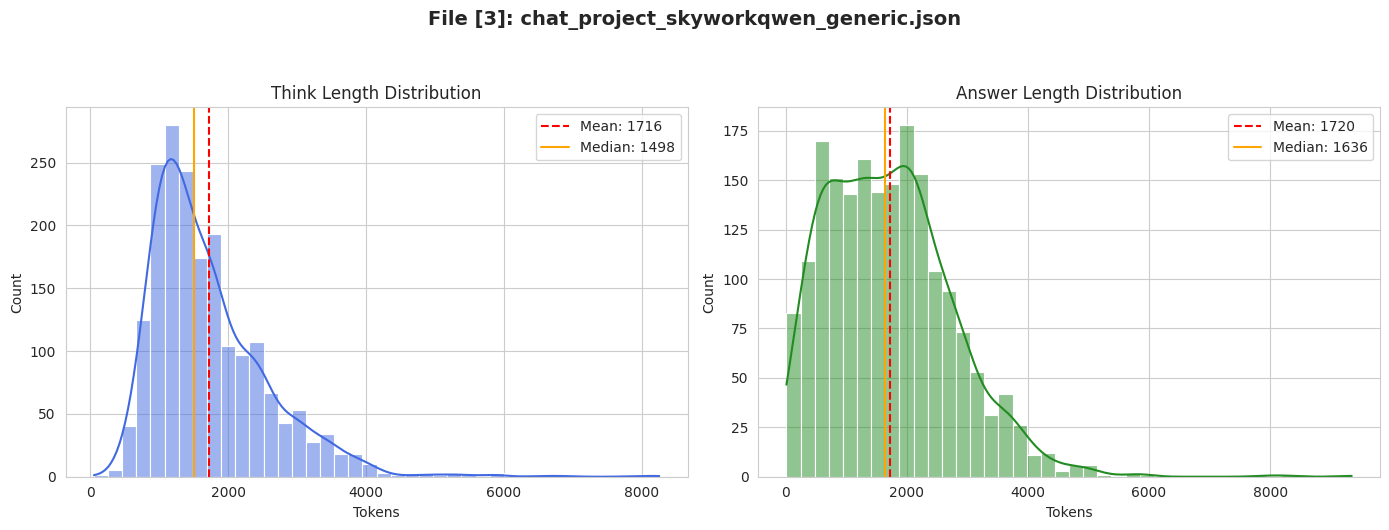

----------------------------------------------------------------------------------------------------


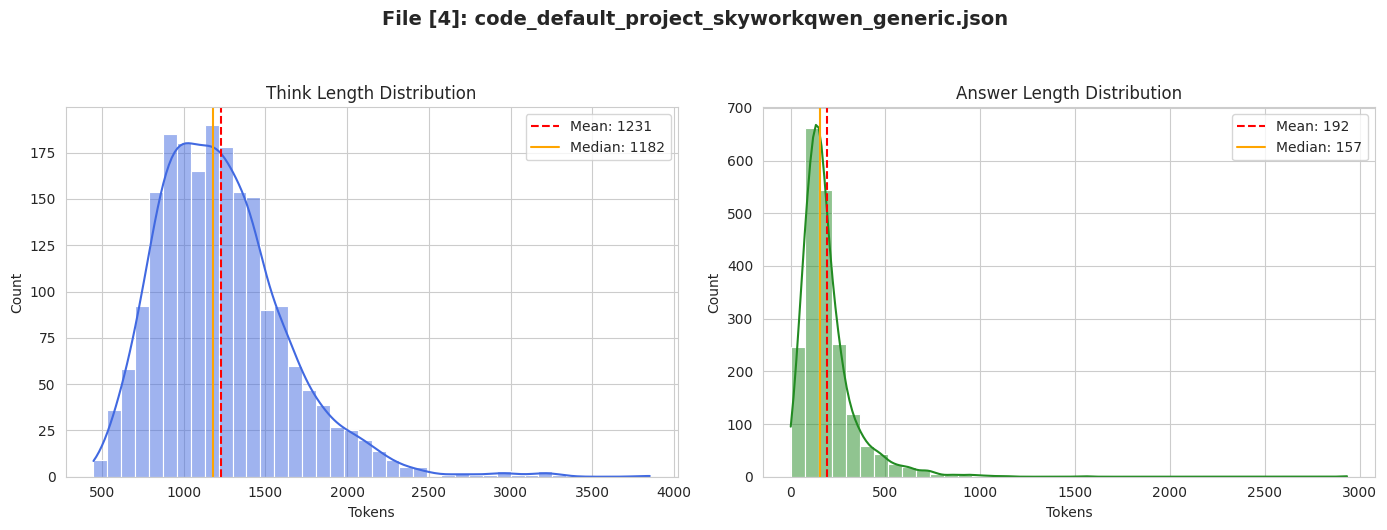

----------------------------------------------------------------------------------------------------


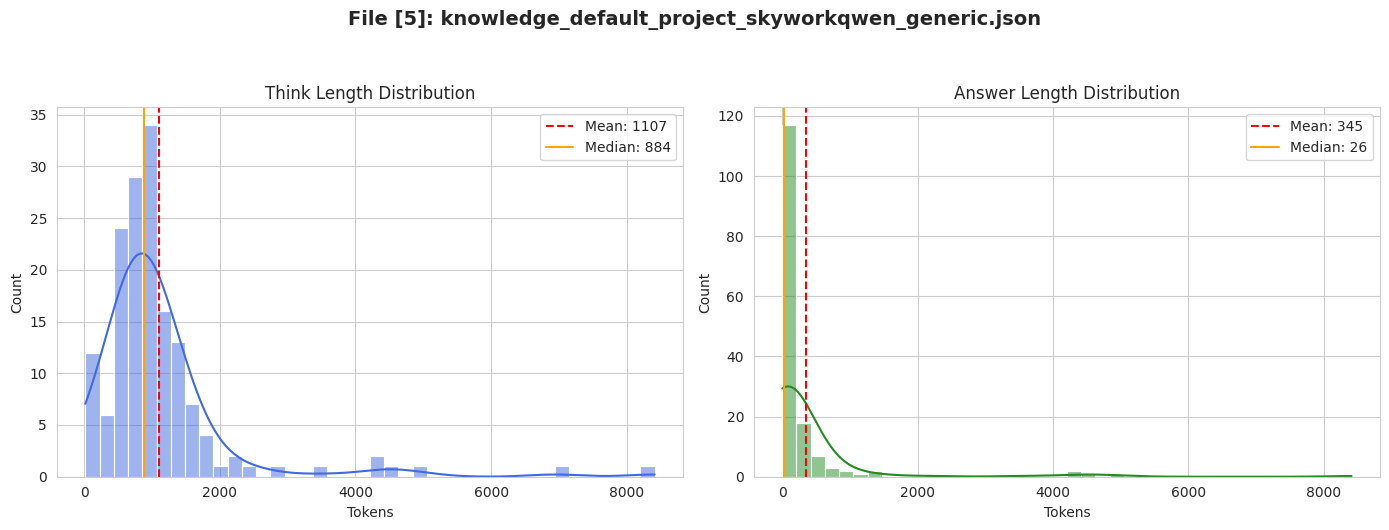

----------------------------------------------------------------------------------------------------


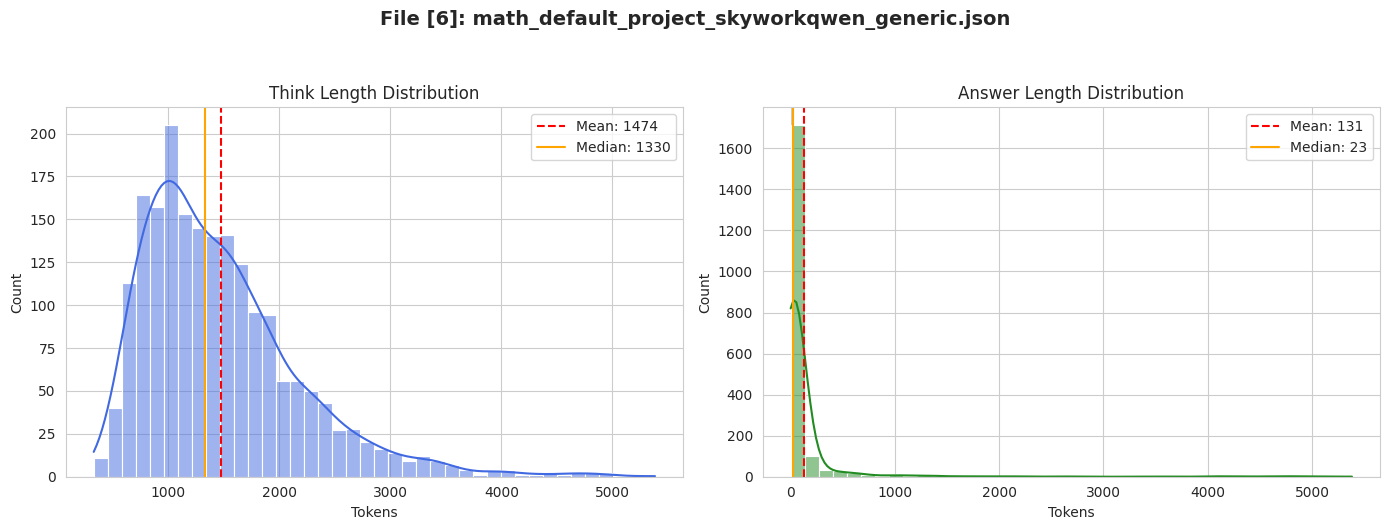

----------------------------------------------------------------------------------------------------


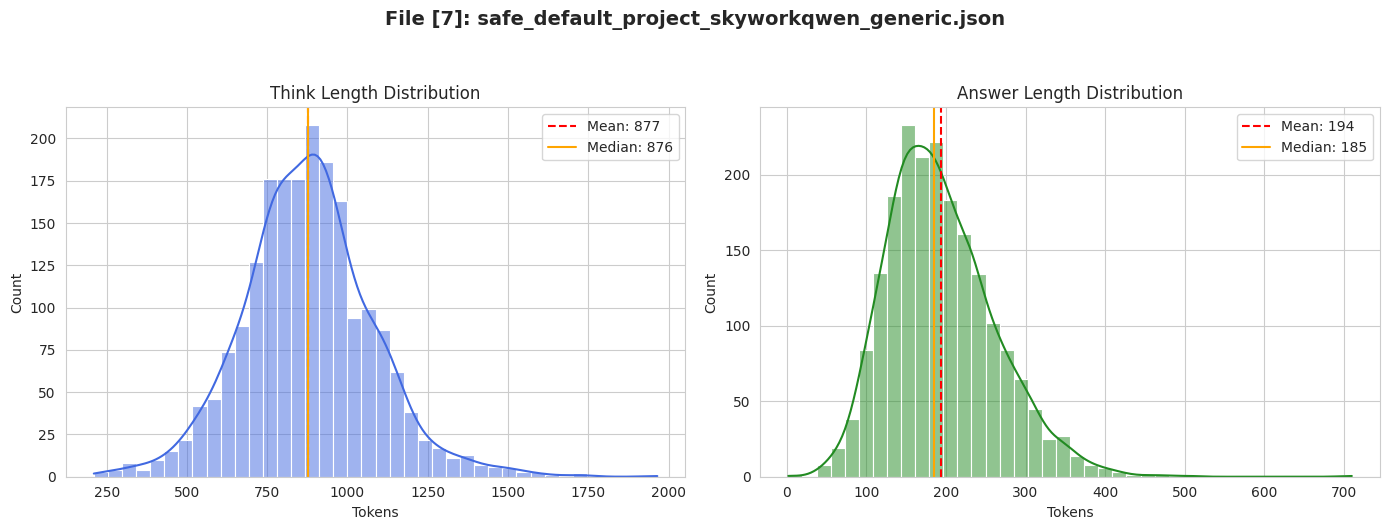

----------------------------------------------------------------------------------------------------


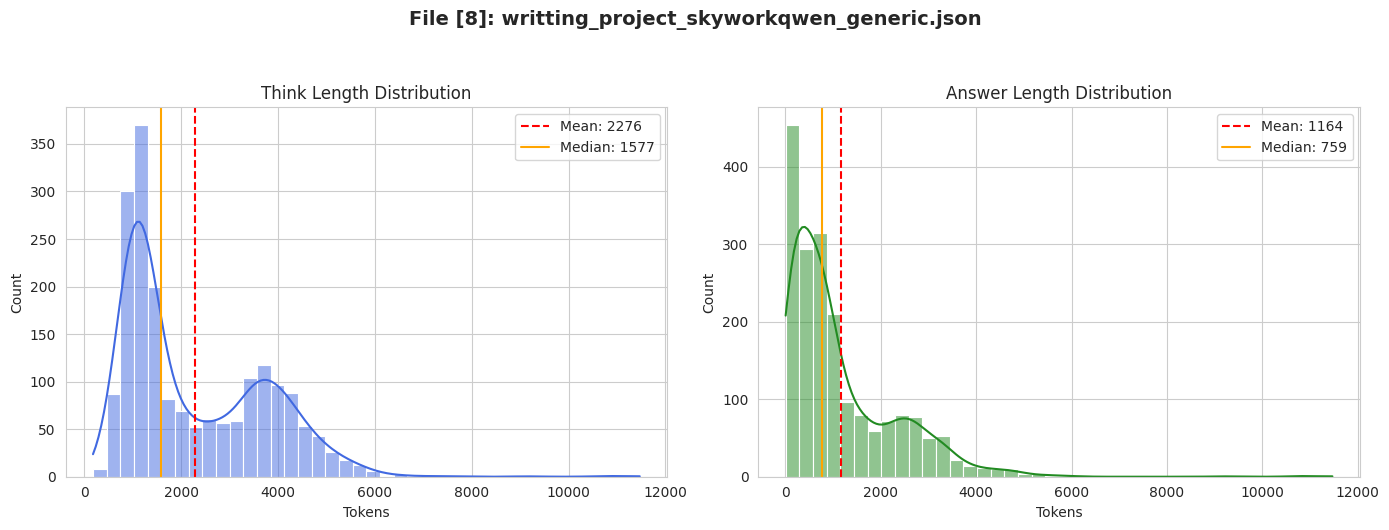

----------------------------------------------------------------------------------------------------


In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

# 在 Notebook 中显示图表（虽然默认就是开启的，但显式声明更稳妥）
%matplotlib inline

# --- 配置路径 ---
base_dir = '/data2/cwli16/data/rollout_for_r1'

# 1. 扫描所有 JSON 文件
json_files = sorted(glob.glob(os.path.join(base_dir, '*.json')))

if not json_files:
    print("❌ 未发现 JSON 文件，请检查路径是否正确。")
else:
    print(f"📂 发现 {len(json_files)} 个文件，正在绘图...")

sns.set_style("whitegrid")

# 2. 循环处理并在 Notebook 中渲染
for idx, file_path in enumerate(json_files):
    file_name = os.path.basename(file_path)
    
    try:
        # 数据加载
        df = pd.read_json(file_path)
        
        # 核心列检查
        if 'think_len' not in df.columns or 'answer_len' not in df.columns:
            continue

        # 数据清洗：剔除长度为 0 的异常数据
        df_clean = df[(df['think_len'] > 0) & (df['answer_len'] > 0)].copy()
        
        if df_clean.empty:
            print(f"⚠️ 文件 {file_name} 清洗后无有效数据。")
            continue

        # --- 开始绘图 ---
        # 增大字体和画布比例
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # 设置总标题
        plt.suptitle(f"File [{idx+1}]: {file_name}", fontsize=14, fontweight='bold', y=1.05)

        # Think Length 直方图
        sns.histplot(df_clean['think_len'], kde=True, color='royalblue', bins=40, ax=ax1)
        ax1.axvline(df_clean['think_len'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {df_clean['think_len'].mean():.0f}")
        ax1.axvline(df_clean['think_len'].median(), color='orange', linestyle='-', 
                    label=f"Median: {df_clean['think_len'].median():.0f}")
        ax1.set_title("Think Length Distribution")
        ax1.set_xlabel("Tokens")
        ax1.legend()

        # Answer Length 直方图
        sns.histplot(df_clean['answer_len'], kde=True, color='forestgreen', bins=40, ax=ax2)
        ax2.axvline(df_clean['answer_len'].mean(), color='red', linestyle='--', 
                    label=f"Mean: {df_clean['answer_len'].mean():.0f}")
        ax2.axvline(df_clean['answer_len'].median(), color='orange', linestyle='-', 
                    label=f"Median: {df_clean['answer_len'].median():.0f}")
        ax2.set_title("Answer Length Distribution")
        ax2.set_xlabel("Tokens")
        ax2.legend()

        # 优化布局并显示
        plt.tight_layout()
        plt.show() # 在 Notebook 中关键是这行，确保每个循环都强制输出图表
        
        # 打印分割线，防止图表粘连
        print("-" * 100)

    except Exception as e:
        print(f"❌ 处理 {file_name} 时出错: {e}")

In [70]:
import pandas as pd
import os
import glob

# --- 配置路径 ---
base_dir = '/data2/cwli16/data/rollout_for_r1'

# 1. 扫描所有 JSON 文件
json_files = sorted(glob.glob(os.path.join(base_dir, '*.json')))

if not json_files:
    print("❌ 未发现 JSON 文件，请检查路径。")
else:
    print(f"📂 发现 {len(json_files)} 个文件，正在提取统计指标...\n")

# 用于存储所有结果以便最后汇总
summary_data = []

# 打印表头
header = f"{'File Name':<40} | {'Count':<6} | {'Think Mean':<10} | {'Think Med':<10} | {'Ans Mean':<10} | {'Ans Med':<10}"
print(header)
print("-" * len(header))

# 2. 循环处理
for file_path in json_files:
    file_name = os.path.basename(file_path)
    
    try:
        df = pd.read_json(file_path)
        
        # 核心列检查
        if 'think_len' not in df.columns or 'answer_len' not in df.columns:
            print(f"⚠️ {file_name:<38} | 缺失必要列")
            continue

        # 数据清洗
        df_clean = df[(df['think_len'] > 0) & (df['answer_len'] > 0)].copy()
        
        if df_clean.empty:
            print(f"⚠️ {file_name:<38} | 无有效数据")
            continue

        # 计算指标
        stats = {
            'File Name': file_name,
            'Count': len(df_clean),
            'Think Mean': df_clean['think_len'].mean(),
            'Think Med': df_clean['think_len'].median(),
            'Ans Mean': df_clean['answer_len'].mean(),
            'Ans Med': df_clean['answer_len'].median()
        }
        summary_data.append(stats)

        # 打印当前行
        print(f"{stats['File Name']:<40} | {stats['Count']:<6} | "
              f"{stats['Think Mean']:>10.1f} | {stats['Think Med']:>10.1f} | "
              f"{stats['Ans Mean']:>10.1f} | {stats['Ans Med']:>10.1f}")

    except Exception as e:
        print(f"❌ {file_name:<38} | 出错: {e}")

# 3. (可选) 生成一个 Pandas DataFrame 汇总，方便在 Notebook 里美化显示
if summary_data:
    print("\n" + "="*40)
    print("✨ 所有数据集汇总表格 (Pandas View):")
    summary_df = pd.DataFrame(summary_data)
    display(summary_df) # Notebook 特有命令，显示漂亮表格

📂 发现 8 个文件，正在提取统计指标...

File Name                                | Count  | Think Mean | Think Med  | Ans Mean   | Ans Med   
-----------------------------------------------------------------------------------------------------
IF_project_skyworkqwen_generic.json      | 1835   |     7200.4 |     7773.0 |      516.5 |      302.0
❌ agent_default_project_skyworkqwen_generic.json | 出错: Expected object or value
chat_project_skyworkqwen_generic.json    | 1908   |     1715.7 |     1498.0 |     1720.4 |     1635.5
code_default_project_skyworkqwen_generic.json | 2000   |     1231.0 |     1181.5 |      192.3 |      157.0
knowledge_default_project_skyworkqwen_generic.json | 157    |     1107.0 |      884.0 |      344.9 |       26.0
math_default_project_skyworkqwen_generic.json | 1956   |     1473.6 |     1330.0 |      130.9 |       23.0
safe_default_project_skyworkqwen_generic.json | 2000   |      877.2 |      875.5 |      193.8 |      185.0
writting_project_skyworkqwen_generic.json | 1920   |   

,File Name,Count,Think Mean,Think Med,Ans Mean,Ans Med
0,IF_project_skyworkqwen_generic.json,1835,7200.360218,7773.0,516.451226,302.0
1,chat_project_skyworkqwen_generic.json,1908,1715.655136,1498.0,1720.366352,1635.5
2,code_default_project_skyworkqwen_generic.json,2000,1230.953500,1181.5,192.253500,157.0
3,knowledge_default_project_skyworkqwen_generic....,157,1106.961783,884.0,344.878981,26.0
4,math_default_project_skyworkqwen_generic.json,1956,1473.575665,1330.0,130.944785,23.0
5,safe_default_project_skyworkqwen_generic.json,2000,877.162500,875.5,193.828500,185.0
6,writting_project_skyworkqwen_generic.json,1920,2275.739062,1577.0,1164.055729,759.0
